In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ASSETS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'SPY', 'GLD']

df = yf.download(ASSETS, start="2018-01-01", end="2024-01-01")['Close']
df.dropna(inplace=True)
df.to_csv("../data/prices.csv")
print(df.shape)
df.head()

[*********************100%***********************]  6 of 6 completed

(1509, 6)


Ticker,AAPL,GLD,JPM,MSFT,NVDA,SPY
Date,,,,,,
2018-01-02,40.304173,125.150002,85.901260,78.870331,4.928267,236.562149
2018-01-03,40.297161,124.820000,85.988800,79.237427,5.252615,238.058533
2018-01-04,40.484337,125.459999,87.220642,79.934799,5.280302,239.061829
2018-01-05,40.945259,125.330002,86.660713,80.925865,5.325049,240.654968
2018-01-08,40.793182,125.309998,86.788704,81.008453,5.488214,241.095078


In [4]:
log_returns = np.log(df / df.shift(1)).dropna()
log_returns.to_csv("../data/log_returns.csv")
log_returns.head()

Ticker,AAPL,GLD,JPM,MSFT,NVDA,SPY
Date,,,,,,
2018-01-03,-0.000174,-0.002640,0.001019,0.004644,0.063739,0.006306
2018-01-04,0.004634,0.005114,0.014224,0.008763,0.005257,0.004206
2018-01-05,0.011321,-0.001037,-0.006440,0.012322,0.008439,0.006642
2018-01-08,-0.003721,-0.000160,0.001476,0.001020,0.030181,0.001827
2018-01-09,-0.000115,-0.004639,0.005056,-0.000680,-0.000271,0.002261


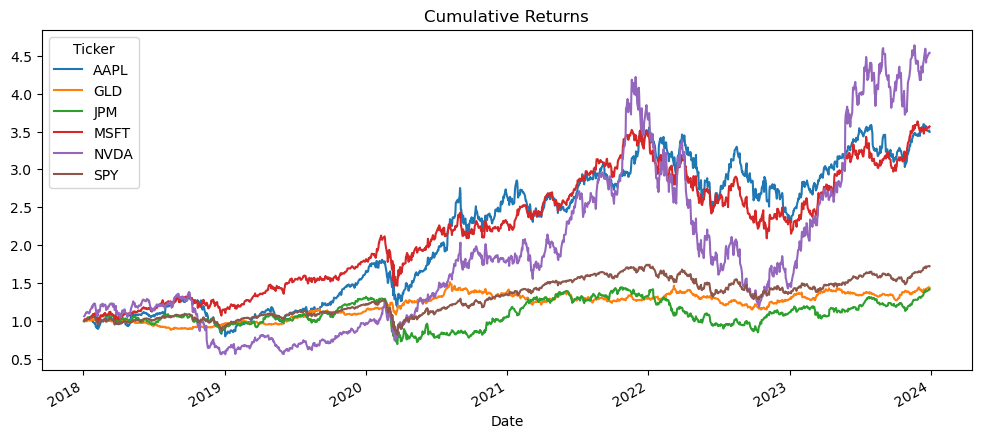

In [7]:
(1 + log_returns).cumprod().plot(figsize=(12, 5), title="Cumulative Returns")
plt.show()

In [8]:
# Download volume data too
df_volume = yf.download(ASSETS, start="2018-01-01", end="2024-01-01")['Volume']
df_volume.dropna(inplace=True)
df_volume.to_csv("../data/volume.csv")
print("Volume data saved!")
df_volume.head()

[*********************100%***********************]  6 of 6 completed

Volume data saved!


Ticker,AAPL,GLD,JPM,MSFT,NVDA,SPY
Date,,,,,,
2018-01-02,102223600,11762500,13578800,22483800,355616000,86655700
2018-01-03,118071600,7904300,11901000,26061400,914704000,90070400
2018-01-04,89738400,7329700,12953700,21912000,583268000,80636400
2018-01-05,94640000,5739900,14155000,23407100,580124000,83524000
2018-01-08,82271200,3566700,12466500,22113000,881216000,57319200
